# Module 1 — Fluorouracil: Statistical Analysis

This notebook applies formal statistical methods to the fluorouracil adverse event data established in the preceding EDA notebooks.

**Analyses planned:**

- **Reporting Odds Ratio (ROR)** - disproportionality analysis to identify signals where a reaction is reported more than expected relative to the full FAERS database. ROR is the standard pharmacovigilance signal detection metric used by FDA and industry.
- **Outcome rate comparisons** - chi-square tests comparing serious outcome rates across drug regimens
- **Descriptive statistics** - summary statistics for age, report volume, and outcome distributions

**Prerequisite:** Run `01_5fu_explore.ipynb` through `04_5fu_outcomes.ipynb` first.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

In [ ]:
import numpy as np

# A: reports with 5-FU AND each reaction
fu_reaction_counts = pd.read_sql_query("""
SELECT r.pt AS reaction, COUNT(DISTINCT r.primaryid) AS A
FROM reac r
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON r.primaryid = f.primaryid
GROUP BY r.pt
ORDER BY A DESC
""", conn)

fu_reaction_counts

# A: reports with 5-FU AND each reaction

,reaction,A
0,Diarrhoea,555
1,Off label use,424
2,Neutropenia,405
3,Nausea,333
4,Disease progression,286
...,...,...
1832,Acidosis,1
1833,Abnormal faeces,1
1834,Abnormal behaviour,1
1835,Abdominal injury,1


In [ ]:
# Total unique 5-FU reports (used to calculate B)
total_fu_reports = pd.read_sql_query("""
SELECT COUNT(DISTINCT primaryid) FROM fluorouracil_analysis
""", conn).iloc[0, 0]


total_fu_reports

np.int64(5617)

In [ ]:
# C: reports WITHOUT 5-FU AND with each reaction
non_fu_reaction_counts = pd.read_sql_query("""
SELECT r.pt AS reaction, COUNT(DISTINCT r.primaryid) AS C
FROM reac r
WHERE r.primaryid NOT IN (SELECT DISTINCT primaryid FROM fluorouracil_analysis)
GROUP BY r.pt
ORDER BY C DESC
""", conn)

non_fu_reaction_counts

,reaction,C
0,Off label use,138086
1,Drug ineffective,96831
2,Fatigue,78981
3,Nausea,63091
4,Diarrhoea,62115
...,...,...
16512,ALK gene rearrangement assay,1
16513,ADAMTS13 activity increased,1
16514,ABO incompatibility,1
16515,5q minus syndrome,1


In [ ]:

# Total reports in full database and total non-5-FU reports (used to calculate D)
total_reports = pd.read_sql_query("""
SELECT COUNT(DISTINCT primaryid) FROM demo
""", conn).iloc[0, 0]
total_non_fu_reports = total_reports - total_fu_reports

total_non_fu_reports

np.int64(1614047)

In [24]:
import numpy as np

# Merge 5-FU reaction counts and non-5-FU reaction counts on reaction term
ror_table = fu_reaction_counts.merge(non_fu_reaction_counts, on='reaction', how='inner')

# B = 5-FU reports without the reaction, D = non-5-FU reports without the reaction
ror_table['B'] = total_fu_reports - ror_table['A']
ror_table['D'] = total_non_fu_reports - ror_table['C']

# Calculate ROR and 95% confidence interval
ror_table['ROR'] = (ror_table['A'] / ror_table['B']) / (ror_table['C'] / ror_table['D'])
ror_table['log_ROR'] = np.log(ror_table['ROR'])
ror_table['SE'] = np.sqrt(1/ror_table['A'] + 1/ror_table['B'] + 1/ror_table['C'] + 1/ror_table['D'])
ror_table['CI_lower'] = np.exp(ror_table['log_ROR'] - 1.96 * ror_table['SE'])
ror_table['CI_upper'] = np.exp(ror_table['log_ROR'] + 1.96 * ror_table['SE'])

# Filter to meaningful signals: ROR > 2, lower CI > 1, minimum 30 reports
ror_signals = ror_table[(ror_table['ROR'] > 2) & (ror_table['CI_lower'] > 1) & (ror_table['A'] >= 30)]
ror_signals = ror_signals.sort_values('ROR', ascending=False)

ror_signals.head(20)



,reaction,A,C,B,D,ROR,log_ROR,SE,CI_lower,CI_upper
66,Colorectal cancer metastatic,53,147,5564,1613900,104.579855,4.649951,0.160782,76.311021,143.320663
61,Arteriospasm coronary,57,235,5560,1613812,70.402024,4.254222,0.148255,52.648697,94.141835
41,Skin toxicity,73,551,5544,1613496,38.558127,3.652167,0.125278,30.163198,49.289508
22,Polyneuropathy,124,1127,5493,1612920,32.307325,3.475294,0.095575,26.788370,38.963298
82,Paronychia,43,426,5574,1613621,29.220889,3.374884,0.160572,21.331042,40.029004
73,Dermatitis acneiform,48,487,5569,1613560,28.557499,3.351920,0.151878,21.205039,38.459292
107,Granulocyte count decreased,32,331,5585,1613716,27.933536,3.329828,0.185609,19.414762,40.190162
58,Haematotoxicity,58,844,5559,1613203,19.942422,2.992849,0.136406,15.263930,26.054900
43,Hypomagnesaemia,67,1243,5550,1612804,15.663625,2.751341,0.126138,12.232686,20.056850
110,Metastases to lymph nodes,31,590,5586,1613457,15.176309,2.719736,0.184750,10.565831,21.798602


In [25]:
ror_signals = ror_table[(ror_table['ROR'] > 2) & (ror_table['CI_lower'] > 1) & (ror_table['A'] >= 30)]
ror_signals = ror_signals.sort_values('ROR', ascending=False)
ror_signals.head(20)


,reaction,A,C,B,D,ROR,log_ROR,SE,CI_lower,CI_upper
66,Colorectal cancer metastatic,53,147,5564,1613900,104.579855,4.649951,0.160782,76.311021,143.320663
61,Arteriospasm coronary,57,235,5560,1613812,70.402024,4.254222,0.148255,52.648697,94.141835
41,Skin toxicity,73,551,5544,1613496,38.558127,3.652167,0.125278,30.163198,49.289508
22,Polyneuropathy,124,1127,5493,1612920,32.307325,3.475294,0.095575,26.788370,38.963298
82,Paronychia,43,426,5574,1613621,29.220889,3.374884,0.160572,21.331042,40.029004
73,Dermatitis acneiform,48,487,5569,1613560,28.557499,3.351920,0.151878,21.205039,38.459292
107,Granulocyte count decreased,32,331,5585,1613716,27.933536,3.329828,0.185609,19.414762,40.190162
58,Haematotoxicity,58,844,5559,1613203,19.942422,2.992849,0.136406,15.263930,26.054900
43,Hypomagnesaemia,67,1243,5550,1612804,15.663625,2.751341,0.126138,12.232686,20.056850
110,Metastases to lymph nodes,31,590,5586,1613457,15.176309,2.719736,0.184750,10.565831,21.798602


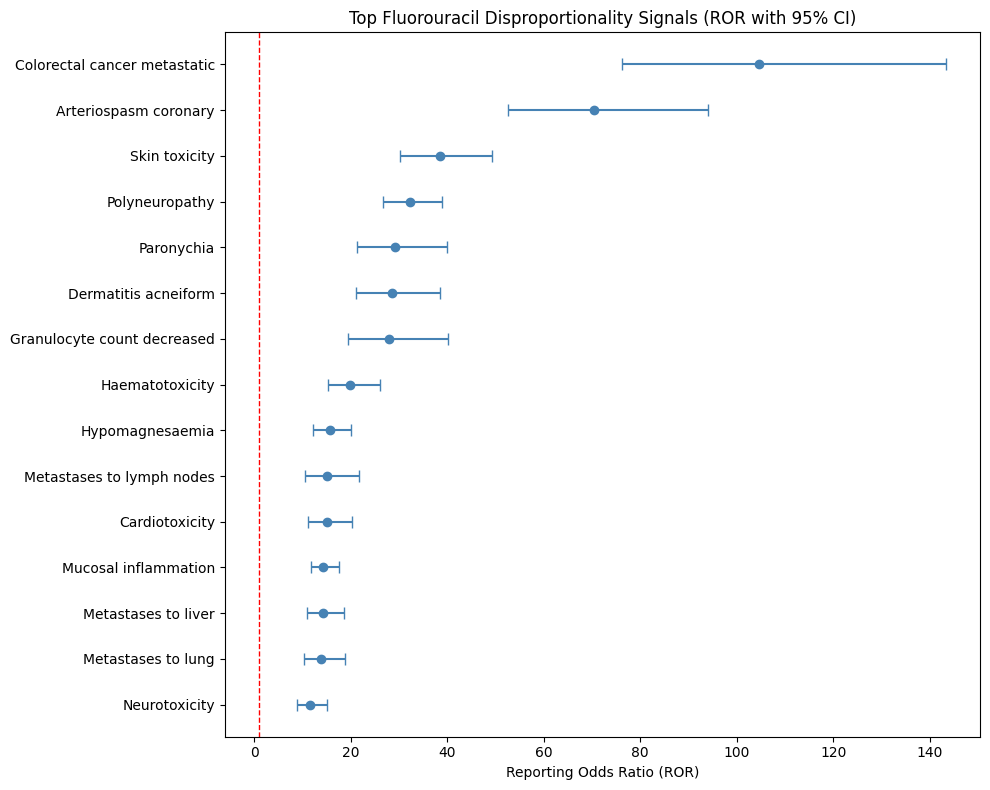

In [26]:
top_ror_signals = ror_signals.head(15).sort_values('ROR')

plt.figure(figsize=(10, 8))
plt.errorbar(
    top_ror_signals['ROR'],
    range(len(top_ror_signals)),
    xerr=[top_ror_signals['ROR'] - top_ror_signals['CI_lower'],
          top_ror_signals['CI_upper'] - top_ror_signals['ROR']],
    fmt='o', color='steelblue', capsize=4
)
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.yticks(range(len(top_ror_signals)), top_ror_signals['reaction'])
plt.xlabel('Reporting Odds Ratio (ROR)')
plt.title('Top Fluorouracil Disproportionality Signals (ROR with 95% CI)')
plt.tight_layout()
plt.show()


### Interpretation

The forest plot above displays the top disproportionality signals for fluorouracil using the
Reporting Odds Ratio (ROR) - the standard signal detection metric used in pharmacovigilance.
Each point represents a reaction's ROR estimate; the horizontal bars are 95% confidence intervals.
Signals to the right of the red reference line (ROR = 1) are reported more than expected relative
to the full FAERS 2024 database.

Several signals align with the established toxicity profile of fluorouracil:

Polyneuropathy and skin toxicity are well-documented adverse effects of fluorouracil-based
  regimens, particularly in combination with oxaliplatin (FOLFOX)

Paronychia and dermatitis acneiform reflect the known cutaneous toxicity of fluorouracil

Cardiotoxicity and stress cardiomyopathy represent a clinically important and often
  underappreciated signal. Fluorouracil-induced cardiotoxicity is an established phenomenon
  estimated to affect 1–18% of patients depending on the regimen and monitoring approach

Mucosal inflammation is consistent with the well-known mucositis associated with
  fluorouracil chemotherapy

Venoocclusive liver disease reflects hepatotoxicity seen in fluorouracil-containing regimens

Reactions appearing as indication terms (e.g., *Colorectal cancer metastatic*) reflect
FAERS reporting behavior where disease status is sometimes logged as a reaction, not true
adverse event signals.

> ROR was calculated using a minimum of 30 reports (A ≥ 30) to reduce noise from rare reactions
> with unreliable estimates. All signals shown have a lower 95% CI bound above 1.


In [ ]:
serious_outcomes_by_FU_regiment = pd.read_sql_query("""
SELECT drug.drugname, outc.outc_cod, COUNT(*) AS reports
FROM drug
JOIN outc ON drug.primaryid = outc.primaryid 
JOIN (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    ON drug.primaryid = f.primaryid
WHERE drugname LIKE '%FLUOROURACIL%'
GROUP BY drugname, outc_cod
ORDER BY reports DESC;
""", conn)

## Chi-Square Test: Outcome Rates by Regimen

**Clinical question:** Do patients on FOLFOX, FOLFIRI, or FOLFIRINOX have a statistically different serious outcome profile compared to fluorouracil monotherapy?

The ROR analysis above told us *which reactions* are over-reported. This test asks whether the *severity of outcomes* (death, hospitalization, life-threatening events) differs meaningfully depending on which regimen the patient received.

**How it works:**
- We build a contingency table: rows = regimen, columns = outcome category, cells = report counts
- Chi-square compares the *observed* counts in each cell against what you would *expect* if regimen and outcome were completely independent
- A low p-value (< 0.05) means the outcome distributions differ more than chance alone can explain

**Limitation to keep in mind:** FOLFIRINOX has a small sample size (~55 reports). Chi-square is less reliable when cell counts are very low, so we will flag any cells below 5.

In [12]:
from scipy.stats import chi2_contingency

# --- Step 1: Pre-identify which primaryids have oxaliplatin or irinotecan ---
# Instead of running correlated EXISTS subqueries for every row (very slow),
# we build two small lookup sets upfront — one scan of the drug table each.
# These become reference tables we join against once, which SQLite handles efficiently.

# Set of primaryids where oxaliplatin was co-reported
oxaliplatin_ids = pd.read_sql_query("""
    SELECT DISTINCT primaryid
    FROM drug
    WHERE drugname LIKE '%OXALIPLATIN%'
""", conn)

# Set of primaryids where irinotecan was co-reported
irinotecan_ids = pd.read_sql_query("""
    SELECT DISTINCT primaryid
    FROM drug
    WHERE drugname LIKE '%IRINOTECAN%'
""", conn)

# Convert to Python sets for fast membership testing
oxa_set = set(oxaliplatin_ids['primaryid'])
iri_set = set(irinotecan_ids['primaryid'])

print(f"Reports with oxaliplatin: {len(oxa_set):,}")
print(f"Reports with irinotecan:  {len(iri_set):,}")

Reports with oxaliplatin: 8,600
Reports with irinotecan:  3,161


In [13]:
# --- Step 2: Pull all fluorouracil primaryids + their outcomes in one query ---
# Simple join between fluorouracil_analysis and outc — no correlated subqueries.
# This runs fast because it's a straightforward inner join on primaryid.

fu_with_outcomes = pd.read_sql_query("""
    SELECT f.primaryid, o.outc_cod AS outcome
    FROM (SELECT DISTINCT primaryid FROM fluorouracil_analysis) f
    JOIN outc o ON f.primaryid = o.primaryid
    WHERE o.outc_cod IN ('DE', 'HO', 'LT', 'OT')
""", conn)

# --- Step 3: Classify each primaryid into a regimen using Python set lookups ---
# Membership testing in a Python set is O(1) — near instant regardless of set size.
# FOLFIRINOX check comes first so triple-combo reports aren't misclassified as FOLFOX.

def classify_regimen(pid):
    in_oxa = pid in oxa_set   # True if this patient also had oxaliplatin reported
    in_iri = pid in iri_set   # True if this patient also had irinotecan reported
    if in_oxa and in_iri:
        return 'FOLFIRINOX'
    elif in_oxa:
        return 'FOLFOX'
    elif in_iri:
        return 'FOLFIRI'
    else:
        return 'Monotherapy'

# Apply the classifier to every row — runs in milliseconds on ~5,600 records
fu_with_outcomes['regimen'] = fu_with_outcomes['primaryid'].map(classify_regimen)

# Count reports per regimen + outcome combination
regimen_outcomes = (
    fu_with_outcomes
    .groupby(['regimen', 'outcome'])
    .size()
    .reset_index(name='reports')
)

regimen_outcomes

,regimen,outcome,reports
0,FOLFIRI,DE,82
1,FOLFIRI,HO,528
2,FOLFIRI,LT,64
3,FOLFIRI,OT,675
4,FOLFIRINOX,DE,150
5,FOLFIRINOX,HO,367
6,FOLFIRINOX,LT,94
7,FOLFIRINOX,OT,874
8,FOLFOX,DE,274
9,FOLFOX,HO,1318


In [14]:
# --- Step 2: Build the contingency table ---
# pivot_table reshapes the long-format query result (one row per regimen+outcome)
# into a wide matrix where:
#   - rows = regimen (FOLFIRI, FOLFOX, FOLFIRINOX, Monotherapy)
#   - columns = outcome code (DE, HO, LT, OT)
#   - values = report counts
# fill_value=0 handles any regimen/outcome combinations with zero reports
# (e.g., if no FOLFIRINOX reports resulted in a life-threatening outcome)

contingency_table = regimen_outcomes.pivot_table(
    index='regimen',
    columns='outcome',
    values='reports',
    fill_value=0
)

# Rename columns from codes to readable labels for display
contingency_table.columns.name = None
contingency_table = contingency_table.rename(columns={
    'DE': 'Death',
    'HO': 'Hospitalization',
    'LT': 'Life-Threatening',
    'OT': 'Other Serious'
})

print("Contingency Table (observed counts):")
print(contingency_table)

# --- Step 3: Check for low cell counts ---
# Chi-square assumptions break down when expected cell counts are < 5.
# We flag this now so we can note it in the interpretation.
# (We check observed counts as a proxy — expected counts will be similar in magnitude)
low_cells = (contingency_table < 5).sum().sum()
print(f"\nCells with count < 5: {low_cells}")
if low_cells > 0:
    print("Warning: some cells have very low counts — interpret chi-square results cautiously.")

Contingency Table (observed counts):
             Death  Hospitalization  Life-Threatening  Other Serious
regimen                                                             
FOLFIRI       82.0            528.0              64.0          675.0
FOLFIRINOX   150.0            367.0              94.0          874.0
FOLFOX       274.0           1318.0             247.0         2074.0
Monotherapy  254.0            791.0             150.0         1097.0

Cells with count < 5: 0


In [15]:
# --- Step 4: Run the chi-square test ---
# chi2_contingency takes the raw count matrix and returns four values:
#   chi2    - the test statistic (how far observed counts deviate from expected)
#   p_value - probability of seeing this result by chance if there's truly no association
#   dof     - degrees of freedom = (rows - 1) * (columns - 1)
#   expected - the matrix of expected counts under the null hypothesis (no association)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic : {chi2:.2f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.4f}")
print()

# Interpret the p-value using the standard 0.05 significance threshold
if p_value < 0.05:
    print("Result: SIGNIFICANT (p < 0.05)")
    print("The outcome distribution differs across regimens more than expected by chance.")
else:
    print("Result: NOT SIGNIFICANT (p >= 0.05)")
    print("No statistically significant difference in outcome distribution across regimens.")

print()
print("Expected counts under null hypothesis (no association between regimen and outcome):")
expected_df = pd.DataFrame(
    expected.round(1),
    index=contingency_table.index,
    columns=contingency_table.columns
)
print(expected_df)

Chi-square statistic : 118.13
Degrees of freedom   : 9
P-value              : 0.0000

Result: SIGNIFICANT (p < 0.05)
The outcome distribution differs across regimens more than expected by chance.

Expected counts under null hypothesis (no association between regimen and outcome):
             Death  Hospitalization  Life-Threatening  Other Serious
regimen                                                             
FOLFIRI      113.4            448.3              82.8          704.4
FOLFIRINOX   124.9            493.5              91.2          775.4
FOLFOX       329.0           1300.4             240.3         2043.3
Monotherapy  192.7            761.7             140.7         1196.8


### Interpretation

The chi-square test evaluates whether the serious outcome profile (death, hospitalization, life-threatening, other serious) is distributed differently across fluorouracil-based regimens or whether it appears uniform regardless of which drugs were co-administered.

**Reading the expected counts table:** Each cell shows the count you would expect if regimen and outcome were completely unrelated. The chi-square statistic measures the total squared deviation between observed and expected counts across all cells — the larger the statistic, the more the data departs from independence.

**FOLFIRINOX caveat:** FOLFIRINOX has a small sample size relative to the other regimens. Where expected cell counts fall below 5, the chi-square approximation is less reliable. These findings should be interpreted directionally rather than conclusively, and would benefit from replication in a larger dataset or a Fisher's exact test for the low-count cells.

**Clinical context:** A significant result does not imply causation — FAERS is a spontaneous reporting database subject to indication bias (sicker patients receive more aggressive combination regimens) and reporting bias. A significant difference in outcome rates between monotherapy and FOLFOX, for example, may reflect patient selection (metastatic patients receiving combination chemotherapy) rather than a true pharmacological difference in toxicity severity.